In [1]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

print(os.getcwd())

c:\Users\Personal\Desktop\programación\airline-delay-pipeline


In [2]:
from src.extract import extract
from src.load import load
from src.transform import run_all_queries
from src.visualize import plot_delays_by_airline, plot_monthly_delay
from src.config import CSV_FOLDER, CSV_TABLE_MAPPING, WEATHER_URL

In [3]:
dataframes = extract(
    CSV_FOLDER,
    CSV_TABLE_MAPPING,
    WEATHER_URL
)

dataframes["weather"].head()

c:\Users\Personal\Desktop\programación\airline-delay-pipeline\src\extract.py:34: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  table_name: read_csv(f"{csv_folder}/{csv_file}")


,number,name,startTime,endTime,isDaytime,temperature,temperatureUnit,temperatureTrend,probabilityOfPrecipitation,windSpeed,windDirection,icon,shortForecast,detailedForecast
0,1,This Afternoon,2026-03-05T13:00:00-05:00,2026-03-05T18:00:00-05:00,True,85,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 31}",10 mph,ESE,https://api.weather.gov/icons/land/day/tsra_hi...,Chance Showers And Thunderstorms,A slight chance of rain showers between 2pm an...
1,2,Tonight,2026-03-05T18:00:00-05:00,2026-03-06T06:00:00-05:00,False,66,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 17}",5 to 10 mph,ESE,https://api.weather.gov/icons/land/night/rain_...,Slight Chance Rain Showers then Patchy Fog,"A slight chance of rain showers before 7pm, th..."
2,3,Friday,2026-03-06T06:00:00-05:00,2026-03-06T18:00:00-05:00,True,85,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 27}",5 to 10 mph,ESE,https://api.weather.gov/icons/land/day/fog/tsr...,Patchy Fog then Chance Showers And Thunderstorms,"Patchy fog before 9am, then a slight chance of..."
3,4,Friday Night,2026-03-06T18:00:00-05:00,2026-03-07T06:00:00-05:00,False,66,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 16}",5 to 10 mph,E,https://api.weather.gov/icons/land/night/rain_...,Slight Chance Rain Showers then Partly Cloudy,A slight chance of rain showers before 7pm. Pa...
4,5,Saturday,2026-03-07T06:00:00-05:00,2026-03-07T18:00:00-05:00,True,86,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 36}",5 to 10 mph,ESE,https://api.weather.gov/icons/land/day/sct/tsr...,Mostly Sunny then Chance Showers And Thunderst...,A chance of showers and thunderstorms after 1p...


In [4]:
load(dataframes)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
results = run_all_queries()

results["delays_by_airline"].head()

,AIRLINE,avg_delay
0,Spirit Air Lines,14.471800
1,Frontier Airlines Inc.,12.504706
2,JetBlue Airways,6.677861
3,Atlantic Southeast Airlines,6.585379
4,American Eagle Airlines Inc.,6.457873


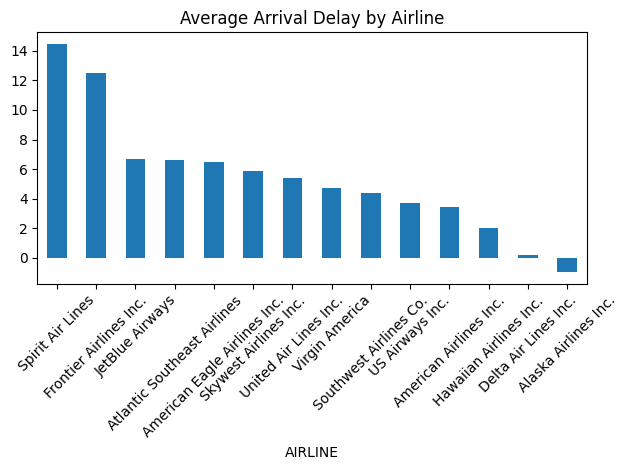

In [6]:
plot_delays_by_airline(results["delays_by_airline"])

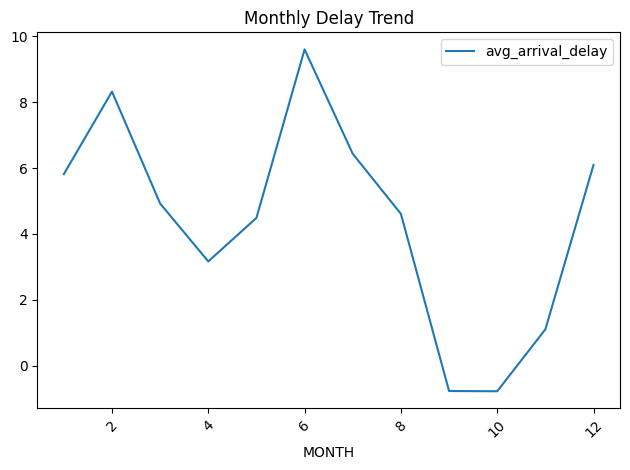

In [7]:
plot_monthly_delay(results["monthly_delay_trend"])